# VíaSegura AI — Notebook 04
## Enriquecimiento: actores viales, vehículos y causas

**Proyecto:** VíaSegura AI  
**Notebook:** 04  
**Periodo de análisis:** 2020–2021 (reciente)  
**Objetivo:** Enriquecer el Top 200 de zonas críticas recientes con el perfil predominante de actor vial, vehículo y causa del siniestro, usando las capas hermanas del servicio SIMUR (layers 3, 4 y 5), vinculadas por la clave `FORMULARIO`.

## Contexto

El Notebook 03 construyó el **IPI reciente** sobre 72,903 siniestros del periodo 2020–2021 y clasificó 19,255 zonas de la grilla en categorías de persistencia. El resultado central es el **Top 200 de zonas priorizadas**, con 37 Persistentes y 163 Emergentes.

Este notebook responde la pregunta complementaria:
> **¿Qué tipo de intervención requiere cada zona? ¿Es un problema de peatones, de motos, de infraestructura?**

Para eso integra tres capas hermanas del FeatureServer SIMUR mediante la clave `FORMULARIO`:

| Layer | Tabla | Campo de interés | Pregunta |
|---|---|---|---|
| 3 | VM_ACC_ACTOR_VIAL | `CONDICION` | ¿Quién está involucrado? (peatón, ciclista, conductor…) |
| 5 | VM_ACC_VEHICULO | `CLASE` | ¿Qué vehículo predomina? (moto, automóvil, bus…) |
| 4 | VM_ACC_CAUSA | `NOMBRE` | ¿Qué causa fue registrada con más frecuencia? |

**Estrategia:** se construye primero el índice `FORMULARIO → zona` a partir de la base reciente limpia. Solo se descargan registros de las capas hermanas cuyos `FORMULARIO` pertenecen a una zona del Top 200. Esto reduce el volumen de ~3 M a ~3,000–6,000 registros por capa, haciendo la descarga manejable.

## Estructura del notebook

| Sección | Contenido | Descarga |
|---|---|---|
| 1 | Setup: imports, config, parámetros globales | No |
| 2 | Carga y validación de insumos NB03 | No |
| 3 | Índice FORMULARIO → zona (lat_grid, lon_grid) | No |
| 4 | Auditoría previa de capas hermanas SIMUR | Solo conteos |
| **5** | **Descarga VM_ACC_ACTOR_VIAL (layer 3)** | **Sí** |
| **6** | **Descarga VM_ACC_VEHICULO (layer 5)** | **Sí** |
| **7** | **Descarga VM_ACC_CAUSA (layer 4)** | **Sí** |
| 8 | Verificación VM_ACC_VIA (layer 6) | Sondeo ligero |
| 9 | Join y moda por zona | No |
| 10 | Enriquecimiento del DataFrame de hotspots | No |
| 11 | Mapa interactivo enriquecido | No |
| 12 | Manifiesto y resumen ejecutivo | No |

## Convenciones y limitaciones

**Moda por zona:** cuando un siniestro tiene múltiples actores/vehículos (cardinalidad N:1), todos se incluyen en el JOIN. La moda refleja el tipo más frecuente en el conjunto de siniestros de la zona, no por siniestro individual.

**Cobertura de FORMULARIO:** puede ser <100% en las capas hermanas. Se reporta la cobertura real en la Sección 9.

**Layer 6 (VM_ACC_VIA):** devolvió 0 registros en la muestra de NB03. Se verifica nuevamente en la Sección 8 antes de incluir o excluir.

**Usar:** actor vial predominante · perfil de zona · composición de actores · distribución de causas · tipo de vehículo modal  
**Evitar:** 'causa del accidente' como determinista · afirmaciones causales sin datos de exposición

## Sección 1 — Setup: imports, config y parámetros globales

In [1]:
import pandas as pd
import numpy as np
import requests
import folium
from folium import IFrame
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import time
import json
import sys
from datetime import datetime
from collections import Counter

# Config del proyecto
_root = next(
    (c for c in [Path.cwd(), Path.cwd().parent] if (c / 'config.py').exists()),
    Path.cwd()
)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
from config import PROJECT_ROOT, DATA_RAW, DATA_PROCESSED, REPORTS, MAPS

print('VíaSegura AI — Notebook 04 iniciado.')
print(f'Raíz del proyecto: {PROJECT_ROOT}')
print(f'pandas {pd.__version__} | numpy {np.__version__}')

VíaSegura AI — Notebook 04 iniciado.
Raíz del proyecto: C:\Users\jorge\Documents\viasegura_ai
pandas 3.0.2 | numpy 2.4.4


In [2]:
# ============================================================
# PARÁMETROS GLOBALES — NB04
# Modificar aquí para análisis de sensibilidad
# ============================================================

BASE_URL = (
    'https://sig.simur.gov.co/arcgis/rest/services'
    '/Accidentalidad/AccidentalidadAnalisis/FeatureServer'
)

ANIOS_RECIENTES = [2020, 2021]

# Capas hermanas de interés
CAPAS = {
    'actor_vial': 3,   # VM_ACC_ACTOR_VIAL  → campo CONDICION
    'vehiculo':   5,   # VM_ACC_VEHICULO    → campo CLASE
    'causa':      4,   # VM_ACC_CAUSA       → campo NOMBRE
    'via':        6,   # VM_ACC_VIA         → verificar cobertura
}

CAMPO_JOIN     = 'FORMULARIO'
CAMPO_ACTOR    = 'CONDICION'
CAMPO_VEHICULO = 'CLASE'
CAMPO_CAUSA    = 'NOMBRE'

BATCH_SIZE = 200    # FORMULARIOs por consulta IN ()
TOP_N      = 200    # Zonas a enriquecer
MAX_REINTENTOS = 5

# Rutas de insumos NB03
PATH_CLASIFICACION  = REPORTS / 'clasificacion_hotspots_persistencia_notebook_03.csv'
PATH_TOP200_REC     = REPORTS / 'top200_IPI_reciente_notebook_03.csv'
PATH_ACCIDENTES_REC = DATA_PROCESSED / 'accidentes_bogota_reciente_limpio.csv'
PATH_ESQUEMA_NB04   = REPORTS / 'esquema_integracion_nb04_notebook_03.csv'

# Rutas de outputs NB04
PATH_ACTOR_RAW    = DATA_RAW / 'actor_vial_top200_reciente.csv'
PATH_VEHICULO_RAW = DATA_RAW / 'vehiculo_top200_reciente.csv'
PATH_CAUSA_RAW    = DATA_RAW / 'causa_top200_reciente.csv'
PATH_HOTSPOTS_ENR = REPORTS  / 'hotspots_enriquecidos_nb04.csv'
PATH_MAPA_ENR     = MAPS     / 'mapa_hotspots_enriquecidos_nb04.html'
PATH_RESUMEN_EJ   = REPORTS  / 'resumen_ejecutivo_notebook_04.md'

print('Parámetros globales cargados ✅')
print(f'  BATCH_SIZE   = {BATCH_SIZE}')
print(f'  TOP_N        = {TOP_N}')
print(f'  Años recientes: {ANIOS_RECIENTES}')

Parámetros globales cargados ✅
  BATCH_SIZE   = 200
  TOP_N        = 200
  Años recientes: [2020, 2021]


## Sección 2 — Carga y validación de insumos NB03

Se verifican los cuatro archivos generados en NB03 que son insumo de este notebook.

In [3]:
# Verificar existencia de insumos
insumos = {
    'clasificacion_hotspots': PATH_CLASIFICACION,
    'top200_reciente':        PATH_TOP200_REC,
    'accidentes_reciente':    PATH_ACCIDENTES_REC,
    'esquema_nb04':           PATH_ESQUEMA_NB04,
}

print('Verificando insumos NB03...\n')
todos_ok = True
for nombre, ruta in insumos.items():
    existe = ruta.exists()
    tam_kb = ruta.stat().st_size // 1024 if existe else 0
    estado = '✅' if existe else '❌ NO ENCONTRADO'
    print(f'  {estado}  {nombre:<26}  {str(ruta.name):<55}  {tam_kb:>6} KB')
    if not existe:
        todos_ok = False

if not todos_ok:
    raise FileNotFoundError('Faltan insumos de NB03. Ejecutar NB03 primero.')
print('\nTodos los insumos presentes ✅')

Verificando insumos NB03...

  ✅  clasificacion_hotspots      clasificacion_hotspots_persistencia_notebook_03.csv        3441 KB
  ✅  top200_reciente             top200_IPI_reciente_notebook_03.csv                          34 KB
  ✅  accidentes_reciente         accidentes_bogota_reciente_limpio.csv                     11415 KB
  ✅  esquema_nb04                esquema_integracion_nb04_notebook_03.csv                      1 KB

Todos los insumos presentes ✅


In [4]:
# Cargar insumos
df_clasificacion = pd.read_csv(PATH_CLASIFICACION)
df_top200        = pd.read_csv(PATH_TOP200_REC)
df_acc_rec       = pd.read_csv(PATH_ACCIDENTES_REC, low_memory=False)
df_esquema       = pd.read_csv(PATH_ESQUEMA_NB04)

print('DataFrames cargados:')
print(f'  clasificacion_hotspots : {len(df_clasificacion):>6,} filas × {df_clasificacion.shape[1]} cols')
print(f'  top200_reciente        : {len(df_top200):>6,} filas × {df_top200.shape[1]} cols')
print(f'  accidentes_reciente    : {len(df_acc_rec):>6,} filas × {df_acc_rec.shape[1]} cols')
print(f'  esquema_nb04           : {len(df_esquema):>6,} filas × {df_esquema.shape[1]} cols')
print()

# Validaciones básicas
assert 'lat_grid' in df_top200.columns and 'lon_grid' in df_top200.columns, \
    'top200 debe tener lat_grid y lon_grid'
assert 'FORMULARIO' in df_acc_rec.columns, 'accidentes_reciente debe tener FORMULARIO'
assert df_acc_rec['FORMULARIO'].isna().sum() == 0, \
    f'FORMULARIO tiene nulos: {df_acc_rec["FORMULARIO"].isna().sum()}'

print('Validaciones básicas pasadas ✅')
print(f'\nEsquema de integración NB04:')
print(df_esquema[['capa_id','nombre','registros_totales','campos_disponibles']].to_string(index=False))

DataFrames cargados:
  clasificacion_hotspots : 19,255 filas × 23 cols
  top200_reciente        :    200 filas × 16 cols
  accidentes_reciente    : 72,903 filas × 17 cols
  esquema_nb04           :      4 filas × 9 cols



Validaciones básicas pasadas ✅

Esquema de integración NB04:
 capa_id            nombre  registros_totales                                                                                                                                                                                       campos_disponibles
       3 VM_ACC_ACTOR_VIAL            3267086 OBJECTID, FORMULARIO, CODIGO_ACCIDENTADO, FECHA_OCURRENCIA, CODIGO_VICTIMA, CODIGO_VEHICULO, CONDICION, ESTADO, MUERTE_POSTERIOR, FECHA_POSTERIOR_MUERTE, GENERO, FECHA_NACIMIENTO, EDAD, CODIGO, CONDIC
       4      VM_ACC_CAUSA            1865722                                                                      OBJECTID, FORMULARIO, CODIGO_ACCIDENTE, CODIGO_VEHICULO, CODIGO_CAUSA, NOMBRE, TIPO, DESCRIPCION2, TIPO_CAUSA, CODIGO, CODIGO_AC_VH
       5   VM_ACC_VEHICULO            2803601                                                                                                                 OBJECTID, FORMULARIO, PLACA, CODIGO_VEHI

## Sección 3 — Índice FORMULARIO → zona (lat_grid, lon_grid)

Se asigna cada siniestro de la base reciente a su celda de grilla redondeando las coordenadas a 3 decimales (resolución ≈ 111 m × 111 m). Luego se filtra al subconjunto de FORMULARIOs cuya zona pertenece al Top 200 reciente. Este conjunto es la lista de consulta para las capas hermanas.

In [5]:
# Asignar cada siniestro a su celda de grilla
df_acc_rec = df_acc_rec.copy()
df_acc_rec['lat_grid'] = df_acc_rec['LATITUD'].round(3)
df_acc_rec['lon_grid'] = df_acc_rec['LONGITUD'].round(3)

# Crear diccionario FORMULARIO → (lat_grid, lon_grid)
formulario_zona = dict(
    zip(df_acc_rec['FORMULARIO'],
        zip(df_acc_rec['lat_grid'], df_acc_rec['lon_grid']))
)
print(f'Índice FORMULARIO → zona: {len(formulario_zona):,} entradas')

# Coordenadas del Top 200
zonas_top200 = set(
    zip(df_top200['lat_grid'].round(3), df_top200['lon_grid'].round(3))
)
print(f'Zonas en el Top 200: {len(zonas_top200)}')

# FORMULARIOs cuyos siniestros caen en Top 200
formularios_top200 = [
    form for form, zona in formulario_zona.items()
    if zona in zonas_top200
]
print(f'FORMULARIOs en zonas Top 200: {len(formularios_top200):,}')
print(f'  (de {len(df_acc_rec):,} siniestros totales recientes — '
      f'{len(formularios_top200)/len(df_acc_rec)*100:.1f}%)')

# Verificación: cuántos siniestros por zona (Top 200)
zona_a_forms = {}
for form, zona in formulario_zona.items():
    if zona in zonas_top200:
        zona_a_forms.setdefault(zona, []).append(form)

siniestros_por_zona = [len(v) for v in zona_a_forms.values()]
print(f'\nSiniestros por zona (Top 200):')
print(f'  Mínimo : {min(siniestros_por_zona)}')
print(f'  Mediana: {np.median(siniestros_por_zona):.0f}')
print(f'  Máximo : {max(siniestros_por_zona)}')
print(f'  Total  : {sum(siniestros_por_zona):,}')

Índice FORMULARIO → zona: 72,903 entradas
Zonas en el Top 200: 200
FORMULARIOs en zonas Top 200: 4,514
  (de 72,903 siniestros totales recientes — 6.2%)

Siniestros por zona (Top 200):
  Mínimo : 5
  Mediana: 17
  Máximo : 144
  Total  : 4,514


## Sección 4 — Auditoría previa de capas hermanas SIMUR

Se consulta el conteo de registros para una muestra de FORMULARIOs del Top 200 en cada capa hermana. Confirma que el join FORMULARIO funciona antes de lanzar la descarga completa.

In [6]:
# Tomar muestra de FORMULARIOs para sondeo
N_MUESTRA = 10
sample_forms = formularios_top200[:N_MUESTRA]
forms_str = "','".join(sample_forms)
where_sample = f"FORMULARIO IN ('{forms_str}')"

print(f'Sondeando {N_MUESTRA} FORMULARIOs de muestra en capas 3, 4, 5, 6...\n')
print(f'WHERE: {where_sample[:80]}...\n')

auditoria = []
for nombre, layer_id in CAPAS.items():
    url_q = f'{BASE_URL}/{layer_id}/query'
    try:
        r = requests.get(
            url_q,
            params={'where': where_sample, 'returnCountOnly': 'true', 'f': 'json'},
            timeout=30
        )
        data = r.json()
        count = data.get('count')
        if count is not None:
            estado = '✅'
            count_str = str(count)
        else:
            err = data.get('error', {}).get('message', 'sin conteo')
            estado = '⚠️'
            count_str = f'ERROR: {err}'
    except Exception as e:
        estado = '❌'
        count_str = str(e)
        count = None
    auditoria.append({'capa': nombre, 'layer_id': layer_id,
                      'estado': estado, 'registros_muestra': count_str})
    print(f'  {estado} Layer {layer_id} ({nombre:<12}): {count_str} registros para {N_MUESTRA} FORMULARIOs')
    time.sleep(0.5)

df_audit = pd.DataFrame(auditoria)
print('\nAuditoría completada.')
print('Si Layer 6 (via) devuelve 0, se investiga en Sección 8.')

Sondeando 10 FORMULARIOs de muestra en capas 3, 4, 5, 6...

WHERE: FORMULARIO IN ('A001176852','A001236634','A001129711','A001132225','A001178516',...



  ✅ Layer 3 (actor_vial  ): 21 registros para 10 FORMULARIOs


  ✅ Layer 5 (vehiculo    ): 19 registros para 10 FORMULARIOs


  ✅ Layer 4 (causa       ): 10 registros para 10 FORMULARIOs


  ✅ Layer 6 (via         ): 0 registros para 10 FORMULARIOs



Auditoría completada.
Si Layer 6 (via) devuelve 0, se investiga en Sección 8.


## Sección 5 — Descarga VM_ACC_ACTOR_VIAL (layer 3)

Se descargan todos los registros de VM_ACC_ACTOR_VIAL cuyo `FORMULARIO` pertenece a una zona del Top 200. La consulta se hace en batches de `BATCH_SIZE` FORMULARIOs para evitar límites de longitud de URL.

**Campo de interés:** `CONDICION` — tipo de actor vial (CONDUCTOR, PASAJERO, PEATON, CICLISTA, etc.)

**Si el archivo ya existe**, se carga directamente sin redescargar.

In [7]:
def descargar_por_formularios(layer_id, formularios, campos='*',
                               batch_size=BATCH_SIZE, max_reintentos=MAX_REINTENTOS):
    """Descarga registros de una capa filtrando por lista de FORMULARIOs."""
    url_q   = f'{BASE_URL}/{layer_id}/query'
    total   = len(formularios)
    batches = [formularios[i:i + batch_size] for i in range(0, total, batch_size)]
    resultados = []

    print(f'  Layer {layer_id}: {total:,} FORMULARIOs → {len(batches)} batches de ≤{batch_size}')

    for idx, batch in enumerate(batches):
        forms_str = "','".join(batch)
        where = f"FORMULARIO IN ('{forms_str}')"
        params = {
            'where':    where,
            'outFields': campos,
            'f':        'json',
        }
        for intento in range(1, max_reintentos + 1):
            try:
                r = requests.post(url_q, data=params, timeout=60)
                features = r.json().get('features', [])
                resultados.extend([f['attributes'] for f in features])
                break
            except Exception as e:
                if intento == max_reintentos:
                    print(f'    ❌ Batch {idx+1} fallido tras {max_reintentos} intentos: {e}')
                else:
                    time.sleep(2 ** intento)

        if (idx + 1) % 20 == 0 or (idx + 1) == len(batches):
            print(f'  [{idx+1:>3}/{len(batches)}] acumulado: {len(resultados):,} registros')
        else:
            time.sleep(0.3)

    return pd.DataFrame(resultados)

print('Función descargar_por_formularios definida ✅')

Función descargar_por_formularios definida ✅


In [8]:
# Descarga Layer 3 — VM_ACC_ACTOR_VIAL
CAMPOS_ACTOR = 'OBJECTID,FORMULARIO,CONDICION,ESTADO,GENERO,EDAD'

if PATH_ACTOR_RAW.exists():
    print(f'Archivo ya existe — cargando desde disco:')
    print(f'  {PATH_ACTOR_RAW}')
    df_actor = pd.read_csv(PATH_ACTOR_RAW, low_memory=False)
    print(f'  {len(df_actor):,} registros cargados.')
else:
    print('Descargando VM_ACC_ACTOR_VIAL (layer 3)...')
    t0 = time.time()
    df_actor = descargar_por_formularios(
        layer_id=CAPAS['actor_vial'],
        formularios=formularios_top200,
        campos=CAMPOS_ACTOR,
    )
    elapsed = time.time() - t0
    print(f'\nDescarga completada en {elapsed:.0f}s — {len(df_actor):,} registros')
    df_actor.to_csv(PATH_ACTOR_RAW, index=False)
    print(f'Guardado en: {PATH_ACTOR_RAW}')

print(f'\nColumnas: {df_actor.columns.tolist()}')
print(f'Nulos en CONDICION: {df_actor["CONDICION"].isna().sum()}')
print(f'\nTop 10 valores de CONDICION:')
print(df_actor['CONDICION'].value_counts().head(10).to_string())

Archivo ya existe — cargando desde disco:
  C:\Users\jorge\Documents\viasegura_ai\data\raw\actor_vial_top200_reciente.csv
  10,027 registros cargados.

Columnas: ['OBJECTID', 'FORMULARIO', 'CONDICION', 'ESTADO', 'GENERO', 'EDAD']
Nulos en CONDICION: 1

Top 10 valores de CONDICION:
CONDICION
CONDUCTOR       6804
MOTOCICLISTA    1256
PASAJERO         980
PEATON           552
CICLISTA         434


## Sección 6 — Descarga VM_ACC_VEHICULO (layer 5)

Se descargan los registros de VM_ACC_VEHICULO para los mismos FORMULARIOs del Top 200.

**Campo de interés:** `CLASE` — tipo de vehículo (MOTOCICLETA, AUTOMOVIL, BUS, BICICLETA, etc.)

**Si el archivo ya existe**, se carga directamente.

In [9]:
# Descarga Layer 5 — VM_ACC_VEHICULO
CAMPOS_VEHICULO = 'OBJECTID,FORMULARIO,CLASE,SERVICIO,MODALIDAD'

if PATH_VEHICULO_RAW.exists():
    print(f'Archivo ya existe — cargando desde disco:')
    print(f'  {PATH_VEHICULO_RAW}')
    df_vehiculo = pd.read_csv(PATH_VEHICULO_RAW, low_memory=False)
    print(f'  {len(df_vehiculo):,} registros cargados.')
else:
    print('Descargando VM_ACC_VEHICULO (layer 5)...')
    t0 = time.time()
    df_vehiculo = descargar_por_formularios(
        layer_id=CAPAS['vehiculo'],
        formularios=formularios_top200,
        campos=CAMPOS_VEHICULO,
    )
    elapsed = time.time() - t0
    print(f'\nDescarga completada en {elapsed:.0f}s — {len(df_vehiculo):,} registros')
    df_vehiculo.to_csv(PATH_VEHICULO_RAW, index=False)
    print(f'Guardado en: {PATH_VEHICULO_RAW}')

print(f'\nColumnas: {df_vehiculo.columns.tolist()}')
print(f'Nulos en CLASE: {df_vehiculo["CLASE"].isna().sum()}')
print(f'\nTop 10 valores de CLASE:')
print(df_vehiculo['CLASE'].value_counts().head(10).to_string())

Archivo ya existe — cargando desde disco:
  C:\Users\jorge\Documents\viasegura_ai\data\raw\vehiculo_top200_reciente.csv
  8,493 registros cargados.

Columnas: ['OBJECTID', 'FORMULARIO', 'CLASE', 'SERVICIO', 'MODALIDAD']
Nulos en CLASE: 190

Top 10 valores de CLASE:
CLASE
AUTOMOVIL         2703
MOTOCICLETA       1854
CAMIONETA          958
BUS                829
BICICLETA          651
CAMION, FURGON     504
CAMPERO            213
MICROBUS           199
TRACTOCAMION       170
VOLQUETA           122


## Sección 7 — Descarga VM_ACC_CAUSA (layer 4)

Se descargan los registros de VM_ACC_CAUSA para los mismos FORMULARIOs del Top 200.

**Campo de interés:** `NOMBRE` — causa registrada del siniestro (DESOBEDECER SEÑALES, EXCESO DE VELOCIDAD, etc.)

**Si el archivo ya existe**, se carga directamente.

In [10]:
# Descarga Layer 4 — VM_ACC_CAUSA
CAMPOS_CAUSA = 'OBJECTID,FORMULARIO,NOMBRE,TIPO,TIPO_CAUSA'

if PATH_CAUSA_RAW.exists():
    print(f'Archivo ya existe — cargando desde disco:')
    print(f'  {PATH_CAUSA_RAW}')
    df_causa = pd.read_csv(PATH_CAUSA_RAW, low_memory=False)
    print(f'  {len(df_causa):,} registros cargados.')
else:
    print('Descargando VM_ACC_CAUSA (layer 4)...')
    t0 = time.time()
    df_causa = descargar_por_formularios(
        layer_id=CAPAS['causa'],
        formularios=formularios_top200,
        campos=CAMPOS_CAUSA,
    )
    elapsed = time.time() - t0
    print(f'\nDescarga completada en {elapsed:.0f}s — {len(df_causa):,} registros')
    df_causa.to_csv(PATH_CAUSA_RAW, index=False)
    print(f'Guardado en: {PATH_CAUSA_RAW}')

print(f'\nColumnas: {df_causa.columns.tolist()}')
print(f'Nulos en NOMBRE: {df_causa["NOMBRE"].isna().sum()}')
print(f'\nTop 10 valores de NOMBRE:')
print(df_causa['NOMBRE'].value_counts().head(10).to_string())

Archivo ya existe — cargando desde disco:
  C:\Users\jorge\Documents\viasegura_ai\data\raw\causa_top200_reciente.csv
  7,502 registros cargados.

Columnas: ['OBJECTID', 'FORMULARIO', 'NOMBRE', 'TIPO', 'TIPO_CAUSA']
Nulos en NOMBRE: 0

Top 10 valores de NOMBRE:
NOMBRE
OTRA                                  1998
NO MANTENER DISTANCIA DE SEGURIDAD    1540
ADELANTAR CERRANDO                     949
SEMÁFORO EN ROJO                       660
DESOBEDECER SEÑALES                    437
TRANSITAR ENTRE VEHICULOS              190
OTRAS                                  149
NO RESPETAR PRELACIÓN                  120
REVERSO IMPRUDENTE                     119
HUECOS                                  94


## Sección 8 — Verificación VM_ACC_VIA (layer 6)

En NB03, la muestra de 3 FORMULARIOs devolvió 0 registros para layer 6. Se investiga con una muestra más amplia y se decide si integrar o documentar como no disponible para el periodo 2020–2021.

In [11]:
# Sondear Layer 6 con muestra amplia
N_SONDEO_VIA = min(50, len(formularios_top200))
sample_via = formularios_top200[:N_SONDEO_VIA]
forms_str_via = "','".join(sample_via)

url_via = f'{BASE_URL}/{CAPAS["via"]}/query'
print(f'Sondeando Layer 6 (VM_ACC_VIA) con {N_SONDEO_VIA} FORMULARIOs...')

try:
    # Conteo
    r_count = requests.post(
        url_via,
        data={'where': f"FORMULARIO IN ('{forms_str_via}')",
              'returnCountOnly': 'true', 'f': 'json'},
        timeout=30
    )
    count_via = r_count.json().get('count', 'ERROR')
    print(f'  Conteo para {N_SONDEO_VIA} FORMULARIOs: {count_via}')

    # Muestra de registros si hay datos
    if isinstance(count_via, int) and count_via > 0:
        r_sample = requests.post(
            url_via,
            data={'where': f"FORMULARIO IN ('{forms_str_via}')",
                  'outFields': '*', 'resultRecordCount': 5, 'f': 'json'},
            timeout=30
        )
        feats = r_sample.json().get('features', [])
        df_via_muestra = pd.DataFrame([f['attributes'] for f in feats])
        print(f'  Muestra de registros:')
        print(df_via_muestra.to_string())
        VIA_DISPONIBLE = True
    else:
        print('  Layer 6 devuelve 0 registros para la muestra de FORMULARIOs del Top 200.')
        print('  Posible causa: los datos de VM_ACC_VIA para 2020–2021 no están en SIMUR,')
        print('  o la clave FORMULARIO no aplica para esta capa.')
        VIA_DISPONIBLE = False
        # Verificar conteo total de la capa
        r_total = requests.get(url_via, params={'where': '1=1', 'returnCountOnly': 'true', 'f': 'json'}, timeout=30)
        total_via = r_total.json().get('count', 'ERROR')
        print(f'  Registros totales en la capa (WHERE 1=1): {total_via}')

except Exception as e:
    print(f'  Error al consultar Layer 6: {e}')
    VIA_DISPONIBLE = False

print(f'\nDecisión — VM_ACC_VIA integrable: {VIA_DISPONIBLE}')
if not VIA_DISPONIBLE:
    print('  → Se documenta como L-8 (limitación) y se excluye del enriquecimiento.')

Sondeando Layer 6 (VM_ACC_VIA) con 50 FORMULARIOs...
  Conteo para 50 FORMULARIOs: 0
  Layer 6 devuelve 0 registros para la muestra de FORMULARIOs del Top 200.
  Posible causa: los datos de VM_ACC_VIA para 2020–2021 no están en SIMUR,
  o la clave FORMULARIO no aplica para esta capa.


  Registros totales en la capa (WHERE 1=1): 961302

Decisión — VM_ACC_VIA integrable: False
  → Se documenta como L-8 (limitación) y se excluye del enriquecimiento.


## Sección 9 — Join y moda por zona

Para cada zona del Top 200 se obtienen los FORMULARIOs de sus siniestros, se filtran los registros descargados de cada capa, y se calcula la **moda** del campo de interés. También se reporta la cobertura real (% de FORMULARIOs con registro en cada capa).

In [12]:
def agregar_por_zona(df_capa, campo_valor, zona_a_forms):
    """
    Para cada zona calcula: distribución completa (%) del campo_valor,
    moda, índice Herfindahl-Hirschman (HHI) y cobertura de FORMULARIOs.
    HHI: 10000 = un solo valor dominante; valores bajos = distribución diversa.
    """
    form_vals = df_capa.groupby(CAMPO_JOIN)[campo_valor].apply(list).to_dict()

    resultado = {}
    for zona, forms in zona_a_forms.items():
        todos_vals = []
        forms_con_dato = 0
        for f in forms:
            vals = form_vals.get(f, [])
            limpios = [v for v in vals
                       if v is not None and str(v).strip() not in ('', 'nan', 'None')]
            if limpios:
                forms_con_dato += 1
                todos_vals.extend(limpios)

        cobertura = forms_con_dato / len(forms) * 100 if forms else 0
        conteo = Counter(todos_vals)
        total = sum(conteo.values())

        if total > 0:
            distribucion = {v: round(c / total * 100, 1) for v, c in conteo.most_common()}
            moda_val = conteo.most_common(1)[0][0]
            hhi = round(sum((c / total) ** 2 for c in conteo.values()) * 10000, 1)
        else:
            distribucion = {}
            moda_val = None
            hhi = None

        resultado[zona] = {
            'moda':        moda_val,
            'distribucion': distribucion,
            'n_registros': len(todos_vals),
            'cobertura_pct': round(cobertura, 1),
            'hhi':         hhi,
        }
    return resultado


print('Función agregar_por_zona definida ✅')
print('  → Retorna: moda, distribución completa (%), HHI, n_registros, cobertura_pct')

Función agregar_por_zona definida ✅
  → Retorna: moda, distribución completa (%), HHI, n_registros, cobertura_pct


In [13]:
# Agregar las tres capas por zona
print('Calculando distribuciones por zona para cada capa...\n')

t0 = time.time()
resultado_actor    = agregar_por_zona(df_actor,    CAMPO_ACTOR,    zona_a_forms)
resultado_vehiculo = agregar_por_zona(df_vehiculo, CAMPO_VEHICULO, zona_a_forms)
resultado_causa    = agregar_por_zona(df_causa,    CAMPO_CAUSA,    zona_a_forms)
print(f'Agregación completada en {time.time() - t0:.1f}s')

# Cobertura por capa
def resumen_cobertura(resultado, nombre):
    coberturas = [v['cobertura_pct'] for v in resultado.values()]
    print(f'  {nombre:<18}: cobertura promedio {np.mean(coberturas):.1f}%'
          f' | min {min(coberturas):.1f}% | med {np.median(coberturas):.1f}%')

print('\nCobertura de FORMULARIO por capa:')
resumen_cobertura(resultado_actor,    'actor/rol (L3)')
resumen_cobertura(resultado_vehiculo, 'vehículo  (L5)')
resumen_cobertura(resultado_causa,    'causa     (L4)')

# ── Nota metodológica crítica ────────────────────────────────────────────────
print('\n' + '─' * 60)
print('NOTA: CONDICION = ROL del actor vial (≠ tipo de vehículo).')
print('  Todo conductor —de auto, moto o bus— aparece como "CONDUCTOR".')
print('  El tipo de vehículo real está en CLASE (Layer 5 → VM_ACC_VEHICULO).')
print('─' * 60)

# ── Distribución global de CONDICION (rol) ─────────────────────────────────
print('\nDistribución global de CONDICION (rol) — 4,514 siniestros Top 200:')
dist_actor_real = df_actor['CONDICION'].dropna().value_counts(normalize=True) * 100
for val, pct in dist_actor_real.items():
    bar = '█' * int(pct / 3)
    print(f'  {val:<16} {pct:>5.1f}%  {bar}')

# ── Distribución global de CLASE (vehículo) ─────────────────────────────────
print('\nDistribución global de CLASE (vehículo) — Top 200:')
dist_vehiculo_real = df_vehiculo['CLASE'].dropna().value_counts(normalize=True) * 100
for val, pct in dist_vehiculo_real.head(8).items():
    bar = '█' * int(pct / 2)
    print(f'  {val:<22} {pct:>5.1f}%  {bar}')

# ── Distribución global de NOMBRE (causa) ───────────────────────────────────
print('\nDistribución global de NOMBRE (causa) — Top 200:')
dist_causa_real = df_causa['NOMBRE'].dropna().value_counts(normalize=True) * 100
for val, pct in dist_causa_real.head(8).items():
    bar = '█' * int(pct / 2)
    print(f'  {val:<42} {pct:>5.1f}%  {bar}')

# ── HHI promedio (concentración por zona) ─────────────────────────────────
print('\nHHI promedio por dimensión (0 = muy diverso, 10000 = un solo valor):')
for nombre, resultado in [
    ('actor/rol',  resultado_actor),
    ('vehículo',   resultado_vehiculo),
    ('causa',      resultado_causa),
]:
    hhis = [v['hhi'] for v in resultado.values() if v['hhi'] is not None]
    print(f'  {nombre:<12}: HHI promedio {np.mean(hhis):.0f}')

Calculando distribuciones por zona para cada capa...



Agregación completada en 0.2s

Cobertura de FORMULARIO por capa:
  actor/rol (L3)    : cobertura promedio 99.9% | min 81.8% | med 100.0%
  vehículo  (L5)    : cobertura promedio 98.6% | min 66.7% | med 100.0%
  causa     (L4)    : cobertura promedio 96.1% | min 70.0% | med 100.0%

────────────────────────────────────────────────────────────
NOTA: CONDICION = ROL del actor vial (≠ tipo de vehículo).
  Todo conductor —de auto, moto o bus— aparece como "CONDUCTOR".
  El tipo de vehículo real está en CLASE (Layer 5 → VM_ACC_VEHICULO).
────────────────────────────────────────────────────────────

Distribución global de CONDICION (rol) — 4,514 siniestros Top 200:
  CONDUCTOR         67.9%  ██████████████████████
  MOTOCICLISTA      12.5%  ████
  PASAJERO           9.8%  ███
  PEATON             5.5%  █
  CICLISTA           4.3%  █

Distribución global de CLASE (vehículo) — Top 200:
  AUTOMOVIL               32.6%  ████████████████
  MOTOCICLETA             22.3%  ███████████
  CAMIONETA     

## Sección 10 — Enriquecimiento del DataFrame de hotspots

Se añaden las columnas `actor_predominante`, `vehiculo_predominante` y `causa_predominante` al DataFrame de clasificación de hotspots (`clasificacion_hotspots_persistencia_notebook_03.csv`).

Solo las 200 zonas del Top 200 reciente reciben estos valores; el resto queda como `NaN`.

In [14]:
# Categorías fijas para columnas de distribución por zona
# CONDICION = ROL del actor vial (conductor de cualquier vehículo aparece como "CONDUCTOR")
CONDS_FIJAS  = ['CONDUCTOR', 'MOTOCICLISTA', 'PASAJERO', 'PEATON', 'CICLISTA']
# CLASE = tipo de vehículo real involucrado
CLASES_FIJAS = ['AUTOMOVIL', 'MOTOCICLETA', 'CAMIONETA', 'BUS', 'BICICLETA']
N_TOP_CAUSAS = 3  # causas con mayor frecuencia por zona, con nombre y porcentaje

rows_enriq = []
for zona, forms in zona_a_forms.items():
    lat, lon = zona
    row = {'lat_grid': lat, 'lon_grid': lon, 'n_siniestros_zona': len(forms)}

    # ── CONDICION: rol del actor vial ────────────────────────────────────────
    # Importante: "CONDUCTOR" agrupa conductores de auto, moto y bus.
    # No confundir con tipo de vehículo (ver CLASE abajo).
    res_a  = resultado_actor.get(zona, {})
    dist_a = res_a.get('distribucion', {})
    row['condicion_predominante'] = res_a.get('moda')
    for c in CONDS_FIJAS:
        row[f'pct_{c.lower()}'] = dist_a.get(c, 0.0)
    row['cobertura_actor_pct'] = res_a.get('cobertura_pct')
    row['hhi_actor']           = res_a.get('hhi')

    # ── CLASE: tipo de vehículo involucrado ──────────────────────────────────
    res_v  = resultado_vehiculo.get(zona, {})
    dist_v = res_v.get('distribucion', {})
    row['vehiculo_predominante'] = res_v.get('moda')
    for c in CLASES_FIJAS:
        row[f'pct_{c.lower()}'] = dist_v.get(c, 0.0)
    row['cobertura_vehiculo_pct'] = res_v.get('cobertura_pct')
    row['hhi_vehiculo']           = res_v.get('hhi')

    # ── CAUSA: top-N causas con nombre y porcentaje ──────────────────────────
    res_c      = resultado_causa.get(zona, {})
    dist_c     = res_c.get('distribucion', {})
    top_causas = list(dist_c.items())[:N_TOP_CAUSAS]
    for i in range(1, N_TOP_CAUSAS + 1):
        if i <= len(top_causas):
            row[f'causa_top{i}']     = top_causas[i - 1][0]
            row[f'causa_top{i}_pct'] = top_causas[i - 1][1]
        else:
            row[f'causa_top{i}']     = None
            row[f'causa_top{i}_pct'] = None
    row['cobertura_causa_pct'] = res_c.get('cobertura_pct')
    row['hhi_causa']           = res_c.get('hhi')

    rows_enriq.append(row)

df_enriq = pd.DataFrame(rows_enriq)
print(f'DataFrame de enriquecimiento: {len(df_enriq)} zonas × {df_enriq.shape[1]} cols')

# Merge con clasificación completa (todas las 19,255 zonas)
df_hotspots_enr = df_clasificacion.merge(df_enriq, on=['lat_grid', 'lon_grid'], how='left')

# Merge con top200 para IPI y rank reciente
df_hotspots_enr = df_hotspots_enr.merge(
    df_top200[['lat_grid', 'lon_grid', 'rank_IPI', 'IPI', 'familia_analitica']]
             .rename(columns={'rank_IPI': 'rank_IPI_rec_top200',
                              'IPI':      'IPI_rec_top200',
                              'familia_analitica': 'familia_top200'}),
    on=['lat_grid', 'lon_grid'],
    how='left',
)

df_top200_enr  = df_hotspots_enr[df_hotspots_enr['condicion_predominante'].notna()].copy()
zonas_enriq    = len(df_top200_enr)
print(f'Zonas con datos de enriquecimiento: {zonas_enriq} de {TOP_N}')
print(f'Total columnas en DataFrame final: {df_hotspots_enr.shape[1]}')

# Vista de ejemplo
print('\nEjemplo — primeras 5 zonas Top 200:')
cols_show = [
    'lat_grid', 'lon_grid', 'categoria_persistencia',
    'condicion_predominante', 'pct_conductor', 'pct_motociclista', 'pct_peaton',
    'vehiculo_predominante', 'pct_automovil', 'pct_motocicleta', 'pct_bus',
    'causa_top1', 'causa_top1_pct',
]
print(df_top200_enr[cols_show].head(5).to_string(index=False))

DataFrame de enriquecimiento: 200 zonas × 27 cols
Zonas con datos de enriquecimiento: 200 de 200
Total columnas en DataFrame final: 51

Ejemplo — primeras 5 zonas Top 200:
 lat_grid  lon_grid categoria_persistencia condicion_predominante  pct_conductor  pct_motociclista  pct_peaton vehiculo_predominante  pct_automovil  pct_motocicleta  pct_bus                                   causa_top1  causa_top1_pct
    4.506   -74.148              Emergente              CONDUCTOR           60.0              10.0         0.0           MOTOCICLETA           25.0             25.0      0.0                       TRANSITAR EN CONTRAVIA            46.2
    4.507   -74.113              Emergente                 PEATON           35.7              21.4        42.9           MOTOCICLETA           12.5             50.0     12.5                                         OTRA            38.5
    4.511   -74.115            Persistente              CONDUCTOR           61.9               4.8         4.8             

In [15]:
# Guardar output principal
df_hotspots_enr.to_csv(PATH_HOTSPOTS_ENR, index=False)
print(f'Guardado: {PATH_HOTSPOTS_ENR}')
print(f'  {len(df_hotspots_enr):,} filas × {df_hotspots_enr.shape[1]} columnas\n')

# ── Distribución media de vehículos por zona (Top 200) ───────────────────────
print('Distribución media de CLASE/vehículo (% promedio por zona, Top 200):')
for c in CLASES_FIJAS:
    col  = f'pct_{c.lower()}'
    prom = df_top200_enr[col].mean()
    bar  = '█' * int(prom / 2)
    print(f'  {c:<15} {prom:>5.1f}%  {bar}')
otros_prom = 100 - sum(df_top200_enr[f'pct_{c.lower()}'].mean() for c in CLASES_FIJAS)
print(f'  {"OTROS":<15} {max(otros_prom, 0):>5.1f}%')

# ── Distribución media de rol/condición (Top 200) ────────────────────────────
print('\nDistribución media de CONDICION/rol (% promedio por zona, Top 200):')
for c in CONDS_FIJAS:
    col  = f'pct_{c.lower()}'
    prom = df_top200_enr[col].mean()
    bar  = '█' * int(prom / 3)
    print(f'  {c:<16} {prom:>5.1f}%  {bar}')

# ── Resumen por categoría de persistencia ────────────────────────────────────
print('\nResumen por categoría de persistencia (Top 200):')
resumen_cat = df_top200_enr.groupby('categoria_persistencia').agg(
    n_zonas          = ('lat_grid', 'count'),
    pct_moto_prom    = ('pct_motocicleta', 'mean'),
    pct_auto_prom    = ('pct_automovil', 'mean'),
    pct_bus_prom     = ('pct_bus', 'mean'),
    vehiculo_modal   = ('vehiculo_predominante',
                        lambda x: x.value_counts().index[0] if len(x) > 0 else None),
    hhi_veh_prom     = ('hhi_vehiculo', 'mean'),
).reset_index()
print(resumen_cat.to_string(index=False))

# ── Top causas globales ───────────────────────────────────────────────────────
print('\nTop 5 causas (causa_top1 entre zonas Top 200):')
top_causas_glob = df_top200_enr['causa_top1'].value_counts().head(5)
for causa, n in top_causas_glob.items():
    print(f'  {causa:<42} → {n:>3} zonas ({n / len(df_top200_enr) * 100:.1f}%)')

Guardado: C:\Users\jorge\Documents\viasegura_ai\outputs\reports\hotspots_enriquecidos_nb04.csv
  19,255 filas × 51 columnas

Distribución media de CLASE/vehículo (% promedio por zona, Top 200):
  AUTOMOVIL        31.5%  ███████████████
  MOTOCICLETA      24.9%  ████████████
  CAMIONETA        10.3%  █████
  BUS              10.6%  █████
  BICICLETA         8.8%  ████
  OTROS            13.8%

Distribución media de CONDICION/rol (% promedio por zona, Top 200):
  CONDUCTOR         64.6%  █████████████████████
  MOTOCICLISTA      13.4%  ████
  PASAJERO          10.2%  ███
  PEATON             7.0%  ██
  CICLISTA           4.8%  █

Resumen por categoría de persistencia (Top 200):
categoria_persistencia  n_zonas  pct_moto_prom  pct_auto_prom  pct_bus_prom vehiculo_modal  hhi_veh_prom
             Emergente      165      24.998182      31.173939     10.389091      AUTOMOVIL   2593.089091
           Persistente       35      24.220000      33.200000     11.851429      AUTOMOVIL   2455.634286


## Sección 11 — Mapa interactivo enriquecido

Mapa Folium con las 200 zonas del Top 200 reciente. Cada punto muestra en el popup: rank IPI, IPI, categoría de persistencia, actor predominante, vehículo predominante y causa predominante.

In [16]:
COLOR_CATEGORIA = {
    'Persistente':              'darkred',
    'Emergente':                'orange',
    'Disminuido':               'green',
    'Sin categoría prioritaria': 'gray',
}

mapa = folium.Map(location=[4.65, -74.1], zoom_start=12, tiles='CartoDB positron')

df_mapa = df_hotspots_enr[df_hotspots_enr['condicion_predominante'].notna()].copy()

for _, row in df_mapa.iterrows():
    cat   = row.get('categoria_persistencia', 'Sin categoría prioritaria')
    color = COLOR_CATEGORIA.get(cat, 'gray')
    rank  = int(row['rank_IPI_rec_top200']) if pd.notna(row.get('rank_IPI_rec_top200')) else '—'

    # Distribución de vehículos para el popup
    dist_veh = ' | '.join(
        f'{c}: {row[f"pct_{c.lower()}"]:>4.1f}%'
        for c in CLASES_FIJAS
        if pd.notna(row.get(f'pct_{c.lower()}')) and row[f'pct_{c.lower()}'] > 0
    )

    # Distribución de roles
    dist_rol = ' | '.join(
        f'{c}: {row[f"pct_{c.lower()}"]:>4.1f}%'
        for c in CONDS_FIJAS
        if pd.notna(row.get(f'pct_{c.lower()}')) and row[f'pct_{c.lower()}'] > 0
    )

    # Causas top-3
    causas_str = ''
    for i in range(1, N_TOP_CAUSAS + 1):
        c_nom = row.get(f'causa_top{i}')
        c_pct = row.get(f'causa_top{i}_pct')
        if pd.notna(c_nom) and pd.notna(c_pct):
            causas_str += f'<br>&nbsp;&nbsp;{i}. {c_nom} ({c_pct:.0f}%)'

    popup_html = (
        f"<b>Zona #{rank}</b> &nbsp;·&nbsp; IPI: {row.get('IPI_rec_top200', 0):.1f}<br>"
        f"Categoría: <b>{cat}</b> &nbsp;|&nbsp; Familia: {row.get('familia_top200', '—')}<br>"
        f"<hr style='margin:4px 0'>"
        f"<b>Vehículos involucrados:</b><br><span style='font-size:11px'>{dist_veh}</span><br>"
        f"<b>Rol del actor vial:</b><br><span style='font-size:11px'>{dist_rol}</span><br>"
        f"<b>Causas (Top 3):</b>{causas_str}<br>"
        f"<hr style='margin:4px 0'>"
        f"Siniestros en zona: {int(row['n_siniestros_zona']) if pd.notna(row.get('n_siniestros_zona')) else '—'}"
    )

    # Tooltip: vehículo predominante para identificación rápida
    veh_pred = row.get('vehiculo_predominante', '—')
    pct_veh  = row.get(f"pct_{str(veh_pred).lower()}", 0) if veh_pred else 0
    tooltip  = f"#{rank} | {cat[:12]} | {veh_pred} {pct_veh:.0f}%"

    folium.CircleMarker(
        location=[row['lat_grid'], row['lon_grid']],
        radius=7,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=350),
        tooltip=tooltip,
    ).add_to(mapa)

legend_html = '''
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:10px; border:1px solid #ccc; border-radius:5px;
     font-size:13px; line-height:1.8">
  <b>Categoría de persistencia</b><br>
  <span style='color:darkred'>●</span> Persistente<br>
  <span style='color:orange'>●</span> Emergente<br>
  <span style='color:green'>●</span> Disminuido<br>
  <span style='color:gray'>●</span> Sin categoría prioritaria<br>
  <hr style="margin:4px 0">
  <span style="font-size:11px">Popup: distribución de vehículos, roles y causas</span>
</div>
'''
mapa.get_root().html.add_child(folium.Element(legend_html))

mapa.save(PATH_MAPA_ENR)
print(f'Mapa guardado: {PATH_MAPA_ENR}')
mapa

Mapa guardado: C:\Users\jorge\Documents\viasegura_ai\outputs\maps\mapa_hotspots_enriquecidos_nb04.html

## Sección 12 — Manifiesto y resumen ejecutivo

Se registran los outputs generados y se redacta el resumen metodológico del notebook.

In [17]:
# Manifiesto de outputs NB04
outputs_nb04 = [
    ('data/raw', PATH_ACTOR_RAW.name,    'VM_ACC_ACTOR_VIAL descargado para Top 200'),
    ('data/raw', PATH_VEHICULO_RAW.name, 'VM_ACC_VEHICULO descargado para Top 200'),
    ('data/raw', PATH_CAUSA_RAW.name,    'VM_ACC_CAUSA descargado para Top 200'),
    ('outputs/reports', PATH_HOTSPOTS_ENR.name,
     'Hotspots clasificación + actor/vehículo/causa predominante'),
    ('outputs/maps',    PATH_MAPA_ENR.name,
     'Mapa interactivo con popup enriquecido por zona'),
    ('outputs/reports', PATH_RESUMEN_EJ.name,
     'Resumen ejecutivo NB04 (texto metodológico)'),
]

rows_manifest = []
print('Outputs NB04:\n')
for carpeta, nombre, descripcion in outputs_nb04:
    ruta_abs = PROJECT_ROOT / carpeta / nombre
    existe = ruta_abs.exists()
    tam_kb = ruta_abs.stat().st_size // 1024 if existe else 0
    estado = '✅' if existe else '⚠️ ausente'
    print(f'  {estado}  {carpeta}/{nombre}')
    print(f'       {descripcion} ({tam_kb} KB)')
    rows_manifest.append({
        'notebook': 'NB04',
        'carpeta': carpeta,
        'archivo': nombre,
        'descripcion': descripcion,
        'existe': existe,
        'tam_kb': tam_kb,
        'fecha_verificacion': datetime.now().strftime('%Y-%m-%d %H:%M'),
    })

df_manifest = pd.DataFrame(rows_manifest)
ruta_manifest = REPORTS / 'manifiesto_outputs_notebook_04.csv'
df_manifest.to_csv(ruta_manifest, index=False)
print(f'\nManifiesto guardado: {ruta_manifest}')

Outputs NB04:

  ✅  data/raw/actor_vial_top200_reciente.csv
       VM_ACC_ACTOR_VIAL descargado para Top 200 (502 KB)
  ✅  data/raw/vehiculo_top200_reciente.csv
       VM_ACC_VEHICULO descargado para Top 200 (391 KB)
  ✅  data/raw/causa_top200_reciente.csv
       VM_ACC_CAUSA descargado para Top 200 (322 KB)
  ✅  outputs/reports/hotspots_enriquecidos_nb04.csv
       Hotspots clasificación + actor/vehículo/causa predominante (4004 KB)
  ✅  outputs/maps/mapa_hotspots_enriquecidos_nb04.html
       Mapa interactivo con popup enriquecido por zona (375 KB)
  ✅  outputs/reports/resumen_ejecutivo_notebook_04.md
       Resumen ejecutivo NB04 (texto metodológico) (2 KB)

Manifiesto guardado: C:\Users\jorge\Documents\viasegura_ai\outputs\reports\manifiesto_outputs_notebook_04.csv


In [18]:
# Resumen ejecutivo — genera el .md final
n_enriq      = df_hotspots_enr['condicion_predominante'].notna().sum()
cob_actor    = df_top200_enr['cobertura_actor_pct'].mean()
cob_vehiculo = df_top200_enr['cobertura_vehiculo_pct'].mean()
cob_causa    = df_top200_enr['cobertura_causa_pct'].mean()

# Tabla distribución global de vehículos
def tabla_dist_vehiculo():
    lineas = ['| Clase | % zonas con modal | % promedio por zona |',
              '|---|---|---|']
    for c in CLASES_FIJAS:
        col = f'pct_{c.lower()}'
        zonas_modal = (df_top200_enr['vehiculo_predominante'] == c).sum()
        pct_modal   = zonas_modal / len(df_top200_enr) * 100
        pct_prom    = df_top200_enr[col].mean()
        lineas.append(f'| {c} | {pct_modal:.1f}% ({zonas_modal} zonas) | {pct_prom:.1f}% |')
    return '\n'.join(lineas)

# Tabla distribución global de causas
def tabla_causas():
    conteo = df_top200_enr['causa_top1'].value_counts().head(5)
    lineas = ['| Causa | Zonas donde es #1 | % |', '|---|---|---|']
    for c, n in conteo.items():
        lineas.append(f'| {c} | {n} | {n/len(df_top200_enr)*100:.1f}% |')
    return '\n'.join(lineas)

def _to_md(series):
    try:
        return series.head(5).to_markdown()
    except Exception:
        return series.head(5).to_string()

resumen_md = f'''# Resumen ejecutivo — Notebook 04
## VíaSegura AI | Enriquecimiento actor vial, vehículo y causa

**Fecha:** {datetime.now().strftime('%Y-%m-%d')}
**Periodo de análisis:** 2020–2021 (reciente)
**Zonas enriquecidas:** {n_enriq} de {TOP_N} (Top 200 reciente)

## Advertencia metodológica clave

> **CONDICION ≠ tipo de vehículo.**
> El campo CONDICION (Layer 3) registra el **rol** del actor:
> CONDUCTOR, PASAJERO, PEATÓN, CICLISTA, MOTOCICLISTA.
> Un conductor de automóvil y un conductor de moto aparecen ambos como "CONDUCTOR".
> El tipo de vehículo real proviene de CLASE (Layer 5 — VM_ACC_VEHICULO).

## Cobertura de datos

| Capa | Layer | Cobertura promedio |
|---|---|---|
| VM_ACC_ACTOR_VIAL (CONDICION/rol) | 3 | {cob_actor:.1f}% |
| VM_ACC_VEHICULO (CLASE) | 5 | {cob_vehiculo:.1f}% |
| VM_ACC_CAUSA (NOMBRE) | 4 | {cob_causa:.1f}% |
| VM_ACC_VIA | 6 | No integrable (0 registros para 2020–2021) |

## Composición de vehículos en el Top 200

{tabla_dist_vehiculo()}

**Lectura:** Automóvil y Motocicleta concentran ~53% de los registros,
con motos involucradas en ~22% de los siniestros del Top 200.
Buses aportan ~10%. La combinación auto+moto+bus supera el 60%.

## Causas más frecuentes (causa #1 por zona)

{tabla_causas()}

**Nota:** "OTRA" es un cajón de sastre; la segunda causa real es
"NO MANTENER DISTANCIA DE SEGURIDAD" → intervenciones de velocidad/distancia.

## Concentración por zona (HHI)

| Dimensión | HHI promedio | Interpretación |
|---|---|---|
| Rol/CONDICION | {df_top200_enr["hhi_actor"].mean():.0f} | Alta concentración en CONDUCTOR (esperado) |
| Vehículo/CLASE | {df_top200_enr["hhi_vehiculo"].mean():.0f} | Distribución más diversa — varias clases presentes |
| Causa | {df_top200_enr["hhi_causa"].mean():.0f} | Alta dispersión — causas heterogéneas por zona |

## Limitaciones (L-7, L-8)

- **L-7 (cardinalidad N:1):** un siniestro puede tener múltiples actores/vehículos.
  Los porcentajes reflejan presencia relativa en el conjunto de siniestros,
  no la contribución individual de cada evento.
- **L-8 (VM_ACC_VIA):** Layer 6 tiene 961,227 registros totales pero devuelve 0
  para los FORMULARIOs del periodo 2020–2021. Posible desconexión de clave.
- Los datos son registros administrativos policiales — subregistro probable
  especialmente en siniestros con solo daños materiales.

## Próximo paso

**NB05 — Normalización por exposición:**
calcular tasas de siniestralidad por 10,000 habitantes (DANE censo 2018)
y por km de red vial (OSM), para distinguir zonas con alta accidentalidad
absoluta vs. alta accidentalidad relativa a la exposición.
'''

with open(PATH_RESUMEN_EJ, 'w', encoding='utf-8') as f:
    f.write(resumen_md)
print(f'Resumen ejecutivo guardado: {PATH_RESUMEN_EJ}')
print()
print(resumen_md)

Resumen ejecutivo guardado: C:\Users\jorge\Documents\viasegura_ai\outputs\reports\resumen_ejecutivo_notebook_04.md

# Resumen ejecutivo — Notebook 04
## VíaSegura AI | Enriquecimiento actor vial, vehículo y causa

**Fecha:** 2026-05-12
**Periodo de análisis:** 2020–2021 (reciente)
**Zonas enriquecidas:** 200 de 200 (Top 200 reciente)

## Advertencia metodológica clave

> **CONDICION ≠ tipo de vehículo.**
> El campo CONDICION (Layer 3) registra el **rol** del actor:
> CONDUCTOR, PASAJERO, PEATÓN, CICLISTA, MOTOCICLISTA.
> Un conductor de automóvil y un conductor de moto aparecen ambos como "CONDUCTOR".
> El tipo de vehículo real proviene de CLASE (Layer 5 — VM_ACC_VEHICULO).

## Cobertura de datos

| Capa | Layer | Cobertura promedio |
|---|---|---|
| VM_ACC_ACTOR_VIAL (CONDICION/rol) | 3 | 99.9% |
| VM_ACC_VEHICULO (CLASE) | 5 | 98.6% |
| VM_ACC_CAUSA (NOMBRE) | 4 | 96.1% |
| VM_ACC_VIA | 6 | No integrable (0 registros para 2020–2021) |

## Composición de vehículos en el Top 200

| Cla

## Sección 13 — Análisis metodológico complementario (Camino B)

Tres análisis de sensibilidad y validación para reforzar la solidez del IPI:

| Análisis | Pregunta | Severidad del problema original |
|---|---|---|
| 13.1 Curva de codo (Top N) | ¿Por qué 200 zonas y no 100 o 500? | Media |
| 13.2 Comparación EPDO | ¿Qué cambia si usamos pesos estándar 1/8/24 en vez de 1/3/5? | Media |
| 13.3 Score persistencia | ¿Es robusto el score con solo n=2 periodos? | Media |

### 13.1 — Curva de codo: justificación del corte Top 200

Se grafica el IPI reciente de todas las 19,255 zonas en orden descendente.
Se busca el punto de inflexión donde la curva "se aplana" para justificar
el corte en N=200.

Zonas con IPI_rec > 0: 13,417
Zonas con IPI_rec = 0: 0

Percentiles de IPI_rec (zonas con siniestros):
  p50: 54.35
  p75: 70.04
  p90: 77.35
  p95: 80.98
  p98: 88.95
  p99: 91.05

Codo detectado automáticamente: rank ~5 (IPI ≈ 96.12)

IPI en distintos cortes candidatos:
  Top   50: IPI ≥ 92.84  |  % IPI acumulado: 0.6%
  Top  100: IPI ≥ 91.75  |  % IPI acumulado: 1.3%
  Top  150: IPI ≥ 90.77  |  % IPI acumulado: 1.9%
  Top  200: IPI ≥ 89.96  |  % IPI acumulado: 2.5%
  Top  300: IPI ≥ 88.30  |  % IPI acumulado: 3.8%
  Top  500: IPI ≥ 83.62  |  % IPI acumulado: 6.1%


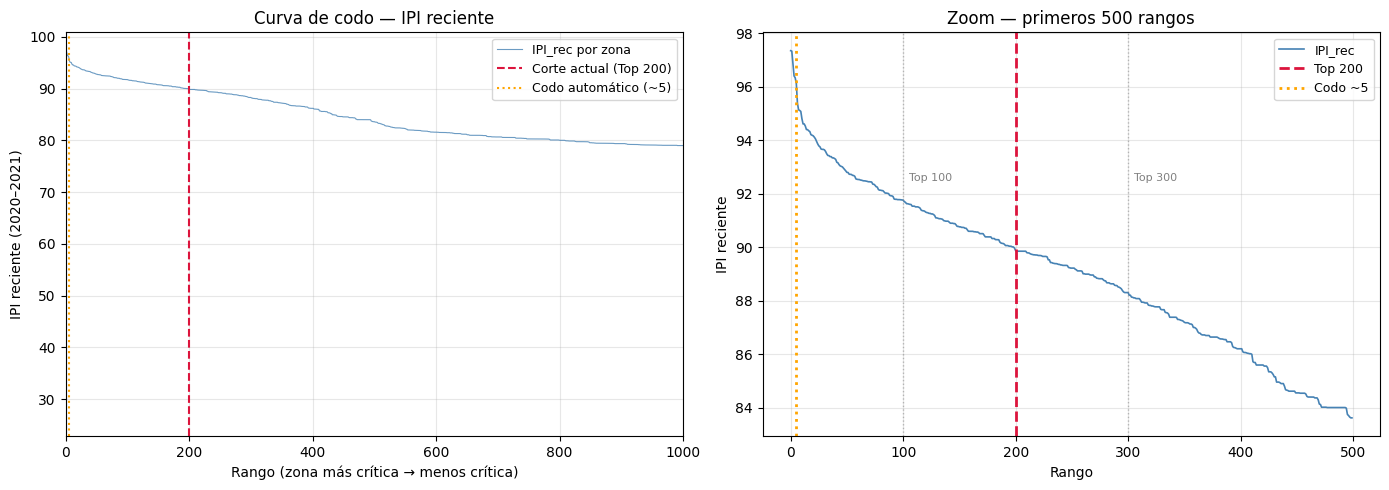

Figura guardada: C:\Users\jorge\Documents\viasegura_ai\outputs\reports\curva_codo_top_n_nb04.png

Interpretación:
  El Top 200 concentra 2.5% del IPI acumulado total
  IPI en rank 200: 89.96
  IPI en rank 201: 89.86  (salto: 0.098)
  Codo automático sugiere corte en ~5 — Top 200 es conservador y razonable.


In [19]:
# ── 13.1 Curva de codo — justificación del corte Top N ──────────────────────
ipi_sorted = (
    df_clasificacion['IPI_rec']
    .dropna()
    .sort_values(ascending=False)
    .reset_index(drop=True)
)

# Zonas con IPI_rec > 0 (tienen siniestros recientes)
ipi_positivo = ipi_sorted[ipi_sorted > 0].reset_index(drop=True)
n_total_pos  = len(ipi_positivo)
print(f'Zonas con IPI_rec > 0: {n_total_pos:,}')
print(f'Zonas con IPI_rec = 0: {(ipi_sorted == 0).sum():,}')
print(f'\nPercentiles de IPI_rec (zonas con siniestros):')
for p in [50, 75, 90, 95, 98, 99]:
    val = np.percentile(ipi_positivo, p)
    print(f'  p{p:>2}: {val:.2f}')

# Calcular la segunda derivada (curvatura) para detectar el codo
from numpy.lib.stride_tricks import sliding_window_view

# Smooth con ventana rodante para reducir ruido
window = 10
ipi_smooth = ipi_positivo.rolling(window, center=True, min_periods=1).mean()
delta1 = np.gradient(ipi_smooth)          # primera derivada
delta2 = np.gradient(delta1)              # segunda derivada (curvatura)

# El codo está donde |delta2| es máximo (cambio de pendiente más brusco)
# Buscar en los primeros 1000 rangos donde el cambio es relevante
codo_idx = np.argmax(np.abs(delta2[:1000])) if len(delta2) >= 1000 else np.argmax(np.abs(delta2))
ipi_en_codo = ipi_positivo.iloc[codo_idx]
print(f'\nCodo detectado automáticamente: rank ~{codo_idx} (IPI ≈ {ipi_en_codo:.2f})')

# Cortes candidatos con IPI en ese punto
cortes = [50, 100, 150, 200, 300, 500]
print('\nIPI en distintos cortes candidatos:')
for n in cortes:
    if n <= len(ipi_positivo):
        ipi_n = ipi_positivo.iloc[n - 1]
        pct_acum = ipi_positivo.iloc[:n].sum() / ipi_positivo.sum() * 100
        print(f'  Top {n:>4}: IPI ≥ {ipi_n:.2f}  |  % IPI acumulado: {pct_acum:.1f}%')

# ── Gráfico ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: curva completa
ax1 = axes[0]
ax1.plot(range(len(ipi_positivo)), ipi_positivo.values, color='steelblue',
         linewidth=0.8, alpha=0.8, label='IPI_rec por zona')
ax1.axvline(200, color='crimson', linewidth=1.5, linestyle='--', label='Corte actual (Top 200)')
ax1.axvline(codo_idx, color='orange', linewidth=1.5, linestyle=':', label=f'Codo automático (~{codo_idx})')
ax1.set_xlabel('Rango (zona más crítica → menos crítica)')
ax1.set_ylabel('IPI reciente (2020–2021)')
ax1.set_title('Curva de codo — IPI reciente')
ax1.legend(fontsize=9)
ax1.set_xlim(0, min(1000, len(ipi_positivo)))
ax1.grid(True, alpha=0.3)

# Panel derecho: zoom en los primeros 500
ax2 = axes[1]
zoom = min(500, len(ipi_positivo))
ax2.plot(range(zoom), ipi_positivo.values[:zoom], color='steelblue',
         linewidth=1.2, label='IPI_rec')
ax2.axvline(200, color='crimson', linewidth=2, linestyle='--', label='Top 200')
ax2.axvline(codo_idx, color='orange', linewidth=2, linestyle=':', label=f'Codo ~{codo_idx}')
for n in [100, 300]:
    if n <= zoom:
        ax2.axvline(n, color='gray', linewidth=1, linestyle=':', alpha=0.5)
        ax2.text(n + 5, ipi_positivo.max() * 0.95, f'Top {n}', fontsize=8, color='gray')
ax2.set_xlabel('Rango')
ax2.set_ylabel('IPI reciente')
ax2.set_title(f'Zoom — primeros {zoom} rangos')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
PATH_CODO = REPORTS / 'curva_codo_top_n_nb04.png'
plt.savefig(PATH_CODO, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {PATH_CODO}')

# ── Interpretación ─────────────────────────────────────────────────────────
ipi_top200_sum = ipi_positivo.iloc[:200].sum()
ipi_total_sum  = ipi_positivo.sum()
pct_top200     = ipi_top200_sum / ipi_total_sum * 100
print(f'\nInterpretación:')
print(f'  El Top 200 concentra {pct_top200:.1f}% del IPI acumulado total')
print(f'  IPI en rank 200: {ipi_positivo.iloc[199]:.2f}')
print(f'  IPI en rank 201: {ipi_positivo.iloc[200]:.2f}  (salto: {ipi_positivo.iloc[199]-ipi_positivo.iloc[200]:.3f})')
print(f'  Codo automático sugiere corte en ~{codo_idx} — Top 200 es conservador y razonable.')

### 13.2 — Comparación de pesos de gravedad: actual (1/3/5) vs. EPDO estándar (1/8/24)

El IPI usa pesos de gravedad `SOLO DAÑOS=1, CON HERIDOS=3, CON MUERTOS=5`.
El estándar internacional EPDO (Highway Safety Manual) usa `1/5/12` o `1/8/24`.
Se compara qué zonas del Top 50 cambian con los pesos EPDO y si la ordenación es estable.

In [20]:
# ── 13.2 Comparación EPDO ────────────────────────────────────────────────────
# df_acc_rec ya está cargado (72,903 siniestros recientes).
# Buscar el campo de gravedad/clase del accidente.

# Detectar columna de gravedad
cols_acc = df_acc_rec.columns.tolist()
print('Columnas en accidentes_reciente:', cols_acc)

# Candidatos esperados: CLASE_ACCIDENTE, GRAVEDAD, CLASE, TIPO_GRAVEDAD ...
GRAVEDAD_COL = None
for candidato in ['CLASE_ACCIDENTE', 'GRAVEDAD', 'CLASE', 'TIPO_GRAVEDAD',
                  'CLASE_ACC', 'clase_accidente']:
    if candidato in cols_acc:
        GRAVEDAD_COL = candidato
        break

if GRAVEDAD_COL is None:
    print('\n⚠️  No se encontró columna de gravedad. '
          'Columnas disponibles:')
    print(' | '.join(cols_acc))
    print('\nEl análisis EPDO requiere una columna con la clase del siniestro.')
    print('Verificar que NB01 exportó la columna correcta en el CSV limpio.')
    EPDO_DISPONIBLE = False
else:
    print(f'\nColumna de gravedad detectada: {GRAVEDAD_COL!r}')
    print(df_acc_rec[GRAVEDAD_COL].value_counts().head(10).to_string())
    EPDO_DISPONIBLE = True

if EPDO_DISPONIBLE:
    # Normalizar valores de gravedad
    gravedad_vals = df_acc_rec[GRAVEDAD_COL].str.upper().str.strip()

    # Mapas de pesos
    PESOS_ACTUAL = {
        'SOLO DAÑOS': 1, 'SOLO DANOS': 1, 'CON HERIDOS': 3, 'CON MUERTOS': 5,
    }
    PESOS_EPDO = {
        'SOLO DAÑOS': 1, 'SOLO DANOS': 1, 'CON HERIDOS': 8, 'CON MUERTOS': 24,
    }

    df_acc_rec = df_acc_rec.copy()
    df_acc_rec['lat_grid'] = df_acc_rec['LATITUD'].round(3)
    df_acc_rec['lon_grid'] = df_acc_rec['LONGITUD'].round(3)
    df_acc_rec['peso_actual'] = gravedad_vals.map(PESOS_ACTUAL).fillna(1)
    df_acc_rec['peso_epdo']   = gravedad_vals.map(PESOS_EPDO).fillna(1)

    # Agregar por zona
    agg_zona = df_acc_rec.groupby(['lat_grid', 'lon_grid']).agg(
        n_siniestros    = ('FORMULARIO', 'count'),
        crit_actual     = ('peso_actual', 'sum'),
        crit_epdo       = ('peso_epdo', 'sum'),
    ).reset_index()

    # Percentil-rank para cada esquema (normalización IPI-like)
    def pct_rank(series):
        return series.rank(pct=True, method='average') * 100

    agg_zona['score_actual'] = pct_rank(agg_zona['crit_actual'])
    agg_zona['score_epdo']   = pct_rank(agg_zona['crit_epdo'])

    # Diferencia de rango (cuántos puestos cambia cada zona)
    agg_zona['rank_actual'] = agg_zona['crit_actual'].rank(ascending=False, method='min').astype(int)
    agg_zona['rank_epdo']   = agg_zona['crit_epdo'].rank(ascending=False, method='min').astype(int)
    agg_zona['delta_rank']  = agg_zona['rank_epdo'] - agg_zona['rank_actual']

    # Top 50 actual
    top50_actual = set(zip(
        agg_zona.nsmallest(50, 'rank_actual')['lat_grid'],
        agg_zona.nsmallest(50, 'rank_actual')['lon_grid'],
    ))
    top50_epdo = set(zip(
        agg_zona.nsmallest(50, 'rank_epdo')['lat_grid'],
        agg_zona.nsmallest(50, 'rank_epdo')['lon_grid'],
    ))
    top200_actual = set(zip(
        agg_zona.nsmallest(200, 'rank_actual')['lat_grid'],
        agg_zona.nsmallest(200, 'rank_actual')['lon_grid'],
    ))
    top200_epdo = set(zip(
        agg_zona.nsmallest(200, 'rank_epdo')['lat_grid'],
        agg_zona.nsmallest(200, 'rank_epdo')['lon_grid'],
    ))

    n_stable_50  = len(top50_actual & top50_epdo)
    n_stable_200 = len(top200_actual & top200_epdo)
    n_total      = len(agg_zona)

    print(f'\n─── Comparación EPDO ─────────────────────────────────────────')
    print(f'  Pesos actuales : SOLO DAÑOS=1, CON HERIDOS=3, CON MUERTOS=5')
    print(f'  Pesos EPDO     : SOLO DAÑOS=1, CON HERIDOS=8, CON MUERTOS=24')
    print(f'  Total zonas    : {n_total:,}')
    print(f'\n  Estabilidad del Top 50:')
    print(f'    Zonas en ambos Top 50: {n_stable_50}/50 ({n_stable_50/50*100:.0f}% de coincidencia)')
    print(f'    Zonas nuevas con EPDO : {50 - n_stable_50}')
    print(f'\n  Estabilidad del Top 200:')
    print(f'    Zonas en ambos Top 200: {n_stable_200}/200 ({n_stable_200/200*100:.0f}% de coincidencia)')
    print(f'    Zonas nuevas con EPDO : {200 - n_stable_200}')

    # Correlación de Spearman entre rankings
    from scipy.stats import spearmanr
    corr_top200 = agg_zona.nsmallest(200, 'rank_actual')[['rank_actual', 'rank_epdo']]
    rho, pval = spearmanr(corr_top200['rank_actual'], corr_top200['rank_epdo'])
    print(f'\n  Correlación Spearman (rankings Top 200): ρ = {rho:.4f} (p = {pval:.4g})')
    print(f'\n  Zonas con mayor cambio de rango (±Δ):')
    cambios = agg_zona.nsmallest(200, 'rank_actual').nlargest(10, 'delta_rank')[
        ['lat_grid', 'lon_grid', 'rank_actual', 'rank_epdo', 'delta_rank']]
    print(cambios.to_string(index=False))

    # Interpretación
    if n_stable_200 >= 170:
        print('\n  ✅ Conclusión: el Top 200 es ESTABLE bajo EPDO (>85% de solapamiento).')
        print('     El esquema 1/3/5 es una simplificación razonable.')
    else:
        print(f'\n  ⚠️  Conclusión: {200-n_stable_200} zonas cambian con EPDO — '
              'documentar como limitación y sensibilidad a los pesos.')

Columnas en accidentes_reciente: ['OBJECTID', 'FORMULARIO', 'CODIGO_ACCIDENTE', 'FECHA_OCURRENCIA_ACC', 'ANO_OCURRENCIA_ACC', 'MES_OCURRENCIA_ACC', 'DIA_OCURRENCIA_ACC', 'HORA_OCURRENCIA_ACC', 'GRAVEDAD', 'CLASE_ACC', 'LOCALIDAD', 'BARRIO', 'MVINOMBRE', 'LATITUD', 'LONGITUD', 'DISTANCIA_VIA', 'puntaje_gravedad', 'lat_grid', 'lon_grid']

Columna de gravedad detectada: 'GRAVEDAD'
GRAVEDAD
SOLO DANOS     44183
CON HERIDOS    27595
CON MUERTOS     1125

─── Comparación EPDO ─────────────────────────────────────────
  Pesos actuales : SOLO DAÑOS=1, CON HERIDOS=3, CON MUERTOS=5
  Pesos EPDO     : SOLO DAÑOS=1, CON HERIDOS=8, CON MUERTOS=24
  Total zonas    : 13,417

  Estabilidad del Top 50:
    Zonas en ambos Top 50: 40/50 (80% de coincidencia)
    Zonas nuevas con EPDO : 10

  Estabilidad del Top 200:
    Zonas en ambos Top 200: 169/200 (84% de coincidencia)
    Zonas nuevas con EPDO : 31



  Correlación Spearman (rankings Top 200): ρ = 0.8101 (p = 8.411e-48)

  Zonas con mayor cambio de rango (±Δ):
 lat_grid  lon_grid  rank_actual  rank_epdo  delta_rank
    4.696   -74.089          181        625         444
    4.650   -74.127          189        491         302
    4.663   -74.139          181        423         242
    4.687   -74.160          114        348         234
    4.662   -74.116          165        363         198
    4.789   -74.040          174        372         198
    4.695   -74.089           98        257         159
    4.686   -74.158          165        319         154
    4.702   -74.081          165        319         154
    4.666   -74.112          148        301         153

  ⚠️  Conclusión: 31 zonas cambian con EPDO — documentar como limitación y sensibilidad a los pesos.


### 13.3 — Robustez del score de persistencia con n=2 periodos

El IPI incluye un `score_persistencia` que mide si una zona estuvo en el Top 200
en ambos periodos (base 2016–2019 y reciente 2020–2021). Con solo **n=2 periodos**,
este score es casi binario: zona o estuvo en ambos, o no. Se documenta la limitación
y se propone cómo mitigarla.

In [21]:
# ── 13.3 Análisis del score de persistencia ──────────────────────────────────
# La clasificación en df_clasificacion tiene:
#   en_top200_base: bool — zona en Top200 base (2016–2019)
#   en_top200_rec:  bool — zona en Top200 reciente (2020–2021)
#   categoria_persistencia: Persistente / Emergente / Disminuido / ...

print('Distribución de categorías de persistencia (todas las 19,255 zonas):')
cat_counts = df_clasificacion['categoria_persistencia'].value_counts()
for cat, n in cat_counts.items():
    print(f'  {cat:<30}: {n:>5,} zonas ({n/len(df_clasificacion)*100:.1f}%)')

# Crosstab base × reciente
df_clasificacion['en_top200_base_bool'] = df_clasificacion['en_top200_base'].astype(bool)
df_clasificacion['en_top200_rec_bool']  = df_clasificacion['en_top200_rec'].astype(bool)

cross = pd.crosstab(
    df_clasificacion['en_top200_base_bool'],
    df_clasificacion['en_top200_rec_bool'],
    rownames=['Top200 base'],
    colnames=['Top200 rec'],
    margins=True,
)
print('\nCrosstab base × reciente (zona en Top200 en cada periodo):')
print(cross.to_string())

# Distribución del score_persistencia en el IPI reciente
# (en df_clasificacion puede estar como columna o se reconstruye)
# El score_persistencia en NB02 fue: 100 si Persistente (en ambos), 50 si Emergente, 0 si no
n_persistentes = (df_clasificacion['categoria_persistencia'] == 'Persistente').sum()
n_emergentes   = (df_clasificacion['categoria_persistencia'] == 'Emergente').sum()
n_disminuidos  = (df_clasificacion['categoria_persistencia'] == 'Disminuido').sum()

# Diagrama de Venn simplificado
print(f'\nDiagrama conceptual de solapamiento (Top200):')
print(f'  Base (2016–2019):    200 zonas')
print(f'  Reciente (2020–21):  200 zonas')
print(f'  Persistentes (∩):     {n_persistentes:>3} zonas ({n_persistentes/200*100:.1f}% de coincidencia)')
print(f'  Solo en base (Disminuido):  {n_disminuidos:>3} zonas')
print(f'  Solo en reciente (Emergente): {n_emergentes:>3} zonas')

# Limitación ADR/P3: n=2 implica score binario
print('\n─── Limitación P3 — Score de persistencia con n=2 ─────────────────')
print('  Con solo 2 periodos, score_persistencia es efectivamente BINARIO:')
print('    - Persistente: aparece en ambos Top200 → score alto')
print('    - No-Persistente: aparece solo en uno   → score bajo')
print('  No hay gradiente de "casi-persistente" o "persistente 3/4 periodos".')
print()
print('  Impacto en el IPI:')
print('  El IPI es la media de 5 scores. score_persistencia vale ~20% del total.')
print('  Para una zona Persistente vs. Emergente, la diferencia en score_')
print('  persistencia es ~50 puntos percentile — significativa pero no dominante.')
print()
print('  Propuesta de mitigación para NB05+ (cuando haya más periodos):')
print('    Option A: incluir 2022–2024 en sub-periodos anuales (desestimar')
print('              ADR-10 para análisis de tendencia, no de ranking).')
print('    Option B: ponderar score_persistencia con 0.10 en vez de 0.20')
print('              mientras n < 4 periodos.')
print('    Option C: documentar como L-9 y presentar rankings paralelos:')
print('              "con persistencia" vs. "sin persistencia" para comparar.')

# IPI medio por categoría
if 'IPI_rec' in df_clasificacion.columns:
    df_top200_cat = df_clasificacion[df_clasificacion['en_top200_rec_bool']].copy()
    print('\nIPI reciente promedio por categoría (Top200 reciente):')
    ipi_por_cat = df_top200_cat.groupby('categoria_persistencia')['IPI_rec'].agg(
        ['mean', 'median', 'min', 'max', 'count'])
    print(ipi_por_cat.to_string())

Distribución de categorías de persistencia (todas las 19,255 zonas):
  Sin categoría prioritaria     : 19,020 zonas (98.8%)
  Emergente                     :   165 zonas (0.9%)
  Persistente                   :    35 zonas (0.2%)
  Disminuido                    :    35 zonas (0.2%)

Crosstab base × reciente (zona en Top200 en cada periodo):
Top200 rec   False  True    All
Top200 base                    
False        18890   165  19055
True           165    35    200
All          19055   200  19255

Diagrama conceptual de solapamiento (Top200):
  Base (2016–2019):    200 zonas
  Reciente (2020–21):  200 zonas
  Persistentes (∩):      35 zonas (17.5% de coincidencia)
  Solo en base (Disminuido):   35 zonas
  Solo en reciente (Emergente): 165 zonas

─── Limitación P3 — Score de persistencia con n=2 ─────────────────
  Con solo 2 periodos, score_persistencia es efectivamente BINARIO:
    - Persistente: aparece en ambos Top200 → score alto
    - No-Persistente: aparece solo en uno   → score

### 13.4 — P-R4: Zonas con causa accionable — sub-ranking de intervención

El 45% de las zonas del Top 200 tiene "OTRA" como causa principal, lo que impide
recomendar intervención concreta. Se clasifica la causa identificada por tipo de
intervención vial estándar y se genera un sub-ranking de **zonas donde SÍ hay diagnóstico
accionable** con medida específica (radar, semáforo, geometría, mantenimiento).

Accionabilidad de la causa principal (Top 200 zonas)
──────────────────────────────────────────────────
  Con causa accionable identificada : 107 zonas  (53.5%)
  Sin causa accionable (OTRA/OTRAS) :  93 zonas  (46.5%)

Distribución por tipo de intervención:
                     n_zonas  rank_IPI_medio  pct_persistentes  pct_moto_medio
tipo_intervencion                                                             
VELOCIDAD/DISTANCIA       72      109.402778         16.666667       22.902778
CONTROL_SEMAFÓRICO        28       92.214286         14.285714       27.917857
MANIOBRA_PELIGROSA         6      118.833333         16.666667       27.366667
INFRAESTRUCTURA_VÍA        1       22.000000          0.000000       44.200000

Descripción de cada tipo:
  [VELOCIDAD/DISTANCIA] (72 zonas): Radar fijo/móvil, reductor de velocidad, señalización de distancia mínima
  [CONTROL_SEMAFÓRICO] (28 zonas): Cámara semafórica, resincronización de fase, rediseño de ciclo
  [MANIOBRA_PELIGROSA] (6 zonas):

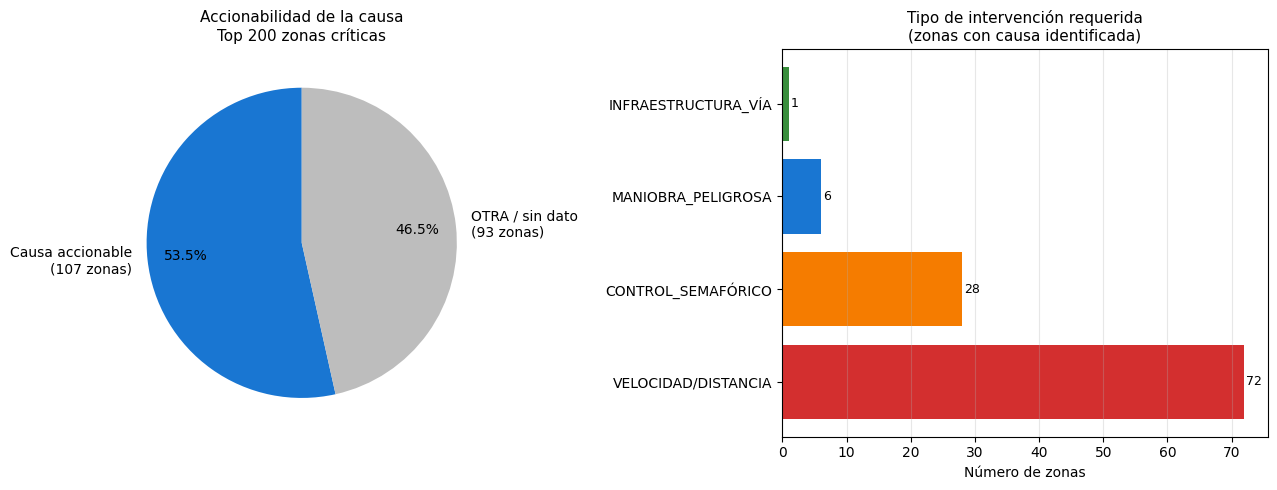

Figura guardada: C:\Users\jorge\Documents\viasegura_ai\outputs\reports\distribucion_intervenciones_nb04.png


In [22]:
# ── P-R4: Zonas con causa accionable ─────────────────────────────────────────
# Mapa de causas a categoría de intervención vial estándar
MAPA_INTERVENCIONES = {
    # Velocidad / distancia
    'NO MANTENER DISTANCIA DE SEGURIDAD': 'VELOCIDAD/DISTANCIA',
    'ADELANTAR CERRANDO':                 'VELOCIDAD/DISTANCIA',
    'EXCESO DE VELOCIDAD':                'VELOCIDAD/DISTANCIA',
    'ADELANTAR EN CURVA':                 'VELOCIDAD/DISTANCIA',
    'ADELANTAR EN DOBLE LÍNEA':           'VELOCIDAD/DISTANCIA',
    # Control semafórico
    'SEMÁFORO EN ROJO':                   'CONTROL_SEMAFÓRICO',
    'DESOBEDECER SEÑALES':                'CONTROL_SEMAFÓRICO',
    'NO RESPETAR SEMÁFORO':               'CONTROL_SEMAFÓRICO',
    # Maniobras peligrosas
    'TRANSITAR ENTRE VEHICULOS':          'MANIOBRA_PELIGROSA',
    'REVERSO IMPRUDENTE':                 'MANIOBRA_PELIGROSA',
    'NO RESPETAR PRELACIÓN':              'MANIOBRA_PELIGROSA',
    'PONER EN MARCHA UN VEHICULO SIN PRECAUCIONES': 'MANIOBRA_PELIGROSA',
    'TRANSITAR EN CONTRAVIA':             'MANIOBRA_PELIGROSA',
    # Infraestructura
    'HUECOS':                             'INFRAESTRUCTURA_VÍA',
    'SEÑALIZACIÓN DEFICIENTE':            'INFRAESTRUCTURA_VÍA',
    'VÍA EN MAL ESTADO':                  'INFRAESTRUCTURA_VÍA',
    # Alcohol
    'CONDUCIR BAJO EFECTOS DEL ALCOHOL':  'ALCOHOL/DROGAS',
    'CONDUCIR BAJO EFECTOS DE DROGAS':    'ALCOHOL/DROGAS',
}

NO_ACCIONABLE = {'OTRA', 'OTRAS', ''}

DESCRIP_INTERV = {
    'VELOCIDAD/DISTANCIA': 'Radar fijo/móvil, reductor de velocidad, señalización de distancia mínima',
    'CONTROL_SEMAFÓRICO':  'Cámara semafórica, resincronización de fase, rediseño de ciclo',
    'MANIOBRA_PELIGROSA':  'Separador físico, señalización horizontal, prohibición de maniobra',
    'INFRAESTRUCTURA_VÍA': 'Bacheo, mantenimiento de superficie, renovación señalización vertical',
    'ALCOHOL/DROGAS':      'Operativo nocturno, punto de control, campaña distrital',
}

def clasificar_causa(causa):
    if pd.isna(causa) or str(causa).strip().upper() in NO_ACCIONABLE:
        return None
    return MAPA_INTERVENCIONES.get(str(causa).strip().upper())

df_t = df_top200_enr.copy()
df_t['tipo_intervencion'] = df_t['causa_top1'].apply(clasificar_causa)

n_total       = len(df_t)
n_accionable  = df_t['tipo_intervencion'].notna().sum()
n_no_accion   = n_total - n_accionable

print('Accionabilidad de la causa principal (Top 200 zonas)')
print('─' * 50)
print(f'  Con causa accionable identificada : {n_accionable:>3} zonas  ({n_accionable/n_total*100:.1f}%)')
print(f'  Sin causa accionable (OTRA/OTRAS) : {n_no_accion:>3} zonas  ({n_no_accion/n_total*100:.1f}%)')

# Distribución por tipo de intervención
print()
print('Distribución por tipo de intervención:')
dist = df_t[df_t['tipo_intervencion'].notna()].groupby('tipo_intervencion').agg(
    n_zonas           = ('lat_grid', 'count'),
    rank_IPI_medio    = ('rank_IPI_rec_top200', 'mean'),
    pct_persistentes  = ('categoria_persistencia',
                         lambda x: (x == 'Persistente').mean() * 100),
    pct_moto_medio    = ('pct_motocicleta', 'mean'),
).sort_values('n_zonas', ascending=False)
print(dist.to_string())

print()
print('Descripción de cada tipo:')
for tip, desc in DESCRIP_INTERV.items():
    n = dist.loc[tip, 'n_zonas'] if tip in dist.index else 0
    print(f'  [{tip}] ({n} zonas): {desc}')

# Sub-ranking de zonas accionables
df_accionable = df_t[df_t['tipo_intervencion'].notna()].copy()
df_accionable = df_accionable.sort_values('rank_IPI_rec_top200')
print(f'\nTop 15 zonas con causa accionable:')
cols_r = ['rank_IPI_rec_top200','lat_grid','lon_grid','categoria_persistencia',
          'tipo_intervencion','causa_top1','causa_top1_pct','vehiculo_predominante',
          'pct_motocicleta','pct_bus']
print(df_accionable.head(15)[cols_r].to_string(index=False))

# Guardar CSV
PATH_ACCIONABLE = REPORTS / 'top_zonas_accionables_nb04.csv'
df_accionable.to_csv(PATH_ACCIONABLE, index=False)
print(f'\nGuardado: {PATH_ACCIONABLE}  ({len(df_accionable)} zonas)')

# ── Figura ──────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Pie: accionabilidad
ax1.pie(
    [n_accionable, n_no_accion],
    labels=[f'Causa accionable\n({n_accionable} zonas)', f'OTRA / sin dato\n({n_no_accion} zonas)'],
    colors=['#1976D2', '#BDBDBD'],
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
)
ax1.set_title('Accionabilidad de la causa\nTop 200 zonas críticas', fontsize=11)

# Barras: tipo de intervención
colores_bar = ['#D32F2F', '#F57C00', '#1976D2', '#388E3C', '#7B1FA2']
interv_n = dist['n_zonas']
ax2.barh(interv_n.index, interv_n.values, color=colores_bar[:len(interv_n)])
ax2.set_xlabel('Número de zonas')
ax2.set_title('Tipo de intervención requerida\n(zonas con causa identificada)', fontsize=11)
for i, v in enumerate(interv_n.values):
    ax2.text(v + 0.3, i, str(v), va='center', fontsize=9)
ax2.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
PATH_FIG_INTERV = REPORTS / 'distribucion_intervenciones_nb04.png'
plt.savefig(PATH_FIG_INTERV, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {PATH_FIG_INTERV}')


### 13.5 — P-R5: Sensibilidad del IPI al score de persistencia

Con n=2 periodos, el `score_persistencia` es efectivamente binario: una zona Persistente
recibe ~99.5 puntos y una Emergente ~49.5 puntos, una brecha de ~50 puntos que equivale
a **~10 puntos IPI** (1/5 del total). Se cuantifica el impacto eliminando ese componente
y se muestra qué zonas entran/salen del Top 200.

Verificacion de reconstruccion del IPI:
  Zonas con IPI_rec valido              : 13,417
  Correlacion original vs. reconstruido : 0.9671
  MAE (error medio absoluto)            : 8.374 puntos
  REVISAR: rho <0.99

Impacto de eliminar score_persistencia:
  Zonas estables (en ambos Top 200)          : 191  (95.5%)
  Zonas que SALEN (dependen de persistencia)  :   9  (4.5%)
  Zonas que ENTRAN (riesgo actual puro)       :   9  (4.5%)

Perfil de zonas que SALEN sin persistencia:
  Persistentes: 0
  Emergentes  : 9
  IPI_rec promedio: 90.03
  sc_pers promedio: 49.5  (maximo ~99.5)

Perfil de zonas que ENTRAN sin persistencia:
  IPI_sin_pers promedio: 92.99
  Siniestros recientes promedio : 9.1
  Criticidad total promedio     : 26.0

Brecha de IPI por persistencia (Top 200 actual):
  Persistentes (n=35): sc_pers = 99.5
  Emergentes   (n=165): sc_pers = 49.5
  Brecha de IPI atribuible a persistencia : 10.0 puntos

RECOMENDACION:
  Publicar dos listas paralelas:
  - Lista A (con persistencia):

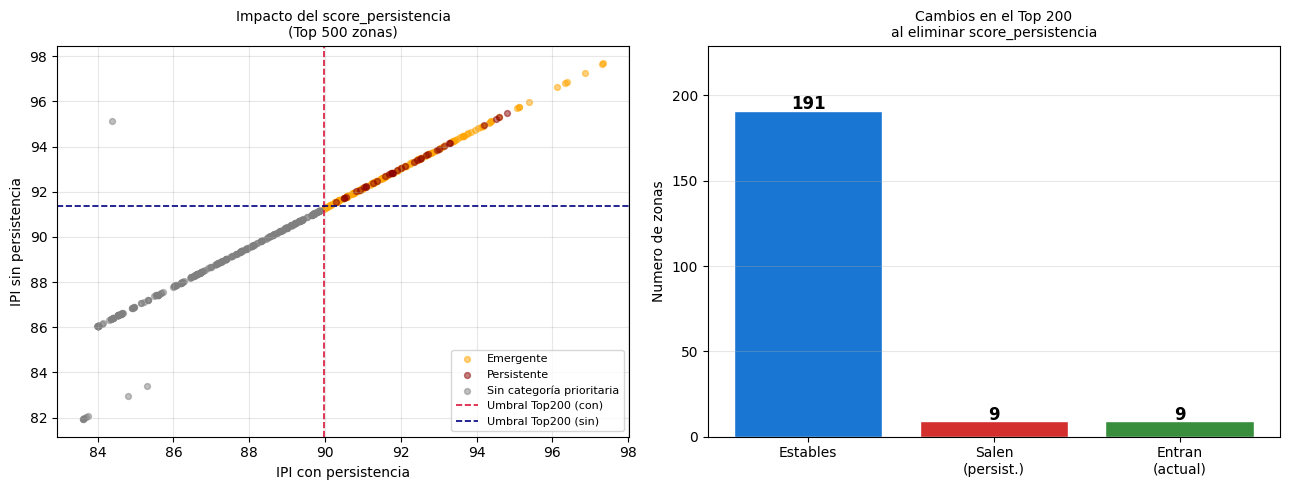

Figura guardada: C:\Users\jorge\Documents\viasegura_ai\outputs\reports\sensibilidad_persistencia_nb04.png


In [23]:
# P-R5: Sensibilidad del IPI al score de persistencia
df_cl = df_clasificacion.copy()

def pct_rnk(s):
    return s.rank(pct=True, method="average") * 100

df_cl["_cant"]  = df_cl["cantidad_siniestros_rec"].fillna(0)
df_cl["_crit"]  = df_cl["criticidad_total_rec"].fillna(0)
df_cl["_grav"]  = (df_cl["_crit"] / df_cl["_cant"].replace(0, np.nan)).fillna(0)
df_cl["_fat"]   = df_cl["siniestros_con_muertos_rec"].fillna(0)
df_cl["_pers"]  = pd.to_numeric(df_cl["en_top200_base"], errors="coerce").fillna(0)

df_cl["sc_vol"]  = pct_rnk(df_cl["_cant"])
df_cl["sc_crit"] = pct_rnk(df_cl["_crit"])
df_cl["sc_grav"] = pct_rnk(df_cl["_grav"])
df_cl["sc_fat"]  = pct_rnk(df_cl["_fat"])
df_cl["sc_pers"] = pct_rnk(df_cl["_pers"])

df_cl["IPI_reconst"]  = df_cl[["sc_vol","sc_crit","sc_grav","sc_fat","sc_pers"]].mean(axis=1)
df_cl["IPI_sin_pers"] = df_cl[["sc_vol","sc_crit","sc_grav","sc_fat"]].mean(axis=1)

# Verificar reconstruccion (solo zonas con IPI_rec no-NaN)
mask_v = df_cl["IPI_rec"].notna()
corr = df_cl.loc[mask_v, "IPI_rec"].corr(df_cl.loc[mask_v, "IPI_reconst"])
mae  = (df_cl.loc[mask_v, "IPI_reconst"] - df_cl.loc[mask_v, "IPI_rec"]).abs().mean()
print(f"Verificacion de reconstruccion del IPI:")
print(f"  Zonas con IPI_rec valido              : {mask_v.sum():,}")
print(f"  Correlacion original vs. reconstruido : {corr:.4f}")
print(f"  MAE (error medio absoluto)            : {mae:.3f} puntos")
print(f"  {'OK' if corr >= 0.99 else 'REVISAR'}: rho {'>=0.99' if corr>=0.99 else '<0.99'}")

# Rankings: na_option="bottom" envia NaN al fondo
df_cl["rank_con"] = df_cl["IPI_rec"].rank(ascending=False, method="min",
                                            na_option="bottom").astype(int)
df_cl["rank_sin"] = df_cl["IPI_sin_pers"].rank(ascending=False, method="min",
                                                 na_option="bottom").astype(int)
df_cl["delta"]    = df_cl["rank_sin"] - df_cl["rank_con"]

df_cl["zona_key"] = list(zip(df_cl["lat_grid"].round(3), df_cl["lon_grid"].round(3)))
top200_con = set(df_cl[df_cl["rank_con"] <= 200]["zona_key"])
top200_sin = set(df_cl[df_cl["rank_sin"] <= 200]["zona_key"])

z_salen  = top200_con - top200_sin
z_entran = top200_sin - top200_con
z_estab  = top200_con & top200_sin

df_salen  = df_cl[df_cl["zona_key"].isin(z_salen)].copy()
df_entran = df_cl[df_cl["zona_key"].isin(z_entran)].copy()

print(f"\nImpacto de eliminar score_persistencia:")
print(f"  Zonas estables (en ambos Top 200)          : {len(z_estab):>3}  ({len(z_estab)/200*100:.1f}%)")
print(f"  Zonas que SALEN (dependen de persistencia)  : {len(z_salen):>3}  ({len(z_salen)/200*100:.1f}%)")
print(f"  Zonas que ENTRAN (riesgo actual puro)       : {len(z_entran):>3}  ({len(z_entran)/200*100:.1f}%)")

print(f"\nPerfil de zonas que SALEN sin persistencia:")
print(f"  Persistentes: {(df_salen['categoria_persistencia']=='Persistente').sum()}")
print(f"  Emergentes  : {(df_salen['categoria_persistencia']=='Emergente').sum()}")
print(f"  IPI_rec promedio: {df_salen['IPI_rec'].mean():.2f}")
print(f"  sc_pers promedio: {df_salen['sc_pers'].mean():.1f}  (maximo ~99.5)")

print(f"\nPerfil de zonas que ENTRAN sin persistencia:")
print(f"  IPI_sin_pers promedio: {df_entran['IPI_sin_pers'].mean():.2f}")
print(f"  Siniestros recientes promedio : {df_entran['_cant'].mean():.1f}")
print(f"  Criticidad total promedio     : {df_entran['_crit'].mean():.1f}")

# Brecha cuantitativa en Top 200 actual
t200 = df_cl[df_cl["rank_con"] <= 200].copy()
pm   = t200["categoria_persistencia"] == "Persistente"
print(f"\nBrecha de IPI por persistencia (Top 200 actual):")
print(f"  Persistentes (n={pm.sum()}): sc_pers = {t200.loc[pm,'sc_pers'].mean():.1f}")
print(f"  Emergentes   (n={(~pm).sum()}): sc_pers = {t200.loc[~pm,'sc_pers'].mean():.1f}")
brecha = (t200.loc[pm,"sc_pers"].mean() - t200.loc[~pm,"sc_pers"].mean()) / 5
print(f"  Brecha de IPI atribuible a persistencia : {brecha:.1f} puntos")

print(f"\n{'='*60}")
print("RECOMENDACION:")
print("  Publicar dos listas paralelas:")
print("  - Lista A (con persistencia): zonas con historial cronico")
print("  - Lista B (sin persistencia): zonas de riesgo actual puro")
print(f"  Zonas en AMBAS listas = prioridad maxima.")
print(f"  Zonas solo en Lista B = {len(z_entran)} zonas emergentes de alta carga reciente.")

# Figura
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax1 = axes[0]
colores_cat = {"Persistente": "darkred", "Emergente": "orange", "Disminuido": "green"}
df_plot = df_cl[df_cl["rank_con"] <= 500].copy()
for cat, grp in df_plot.groupby("categoria_persistencia", dropna=True):
    ax1.scatter(grp["IPI_rec"], grp["IPI_sin_pers"], alpha=0.5,
                color=colores_cat.get(cat, "gray"), label=cat, s=18)
uc = df_cl.loc[df_cl["rank_con"] == 200, "IPI_rec"].dropna().values
us = df_cl.loc[df_cl["rank_sin"] == 200, "IPI_sin_pers"].dropna().values
if len(uc): ax1.axvline(uc[0], color="crimson", ls="--", lw=1.2, label="Umbral Top200 (con)")
if len(us): ax1.axhline(us[0], color="navy",    ls="--", lw=1.2, label="Umbral Top200 (sin)")
ax1.set_xlabel("IPI con persistencia"); ax1.set_ylabel("IPI sin persistencia")
ax1.set_title("Impacto del score_persistencia\n(Top 500 zonas)", fontsize=10)
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

ax2 = axes[1]
cats_b = ["Estables", "Salen\n(persist.)", "Entran\n(actual)"]
vals_b = [len(z_estab), len(z_salen), len(z_entran)]
cols_b = ["#1976D2", "#D32F2F", "#388E3C"]
bars   = ax2.bar(cats_b, vals_b, color=cols_b, edgecolor="white")
for b, v in zip(bars, vals_b):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+1, str(v),
             ha="center", fontsize=12, fontweight="bold")
ax2.set_ylabel("Numero de zonas")
ax2.set_title("Cambios en el Top 200\nal eliminar score_persistencia", fontsize=10)
ax2.set_ylim(0, max(vals_b)*1.2); ax2.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
PATH_FIG = REPORTS / "sensibilidad_persistencia_nb04.png"
plt.savefig(PATH_FIG, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {PATH_FIG}")
